In [3]:
import pandas as pd 

def load_data(file_path):
    """ 
    loads the dataset from a CSV file or JSON file into a pandas DataFrame

    The function checks the file extension to choose the proper loading method.
    If the file is not in a supported format then a ValueError is raised. 
    Any errors encountered during the data loading are printed out and the function returns None.

    Args: 
        file_path: str
        The path to the dataset file. Must end with csv or json

    Returns:
        pandas DataFrame or None

    """

    if file_path.endswith(".csv"):
        df = pd.read_csv(file_path,
        encoding="cp1252",
        quotechar='"',
        low_memory=False
    )
        
    elif file_path.endswith(".json"):
        df = pd.read_json(file_path)
    else:
        raise ValueError("Unsupported file format")

    print("Data loaded successfully")

    return df

In [4]:
import pandas as pd
import numpy as np

def standardize(df):
    df = df.rename(columns={
        "Date of Sale (dd/mm/yyyy)": "date",
        "Address": "address",
        "County": "county",
        "Eircode": "eircode",
        "Price (€)": "price",
        "Not Full Market Price": "not_full_market_price",
        "VAT Exclusive": "vat_exclusive",
        "Description of Property": "property_type",
        "Property Size Description": "property_size"
    })
    

    df["date"] = pd.to_datetime(df["date"],format="%d/%m/%Y",errors="coerce")
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    df["county"] = df["county"].str.strip().str.lower()

    df["price"] = pd.to_numeric(
        df["price"]
        .str.replace("€", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    df.columns = df.columns.str.lower().str.strip()
    df = df.drop_duplicates()

    return df

In [5]:
import pandas as pd
import numpy as np


def analysis(df):
    print(f'Rows:     {len(df):,}')
    print(f'Columns:  {df.shape[1]}')
    print(f'Date range: {df["date"].min().date()} -> {df["date"].max().date()}')

    stats = df['price'].describe(percentiles=[.1, .25, .5, .75, .9])
    labels = ['Min', '10th %ile', '25th %ile', 'Median', '75th %ile', '90th %ile', 'Max']
    values = [stats['min'], stats['10%'], stats['25%'], stats['50%'], stats['75%'], stats['90%'], stats['max']]

    print('National price distribution (all years):')
    print('-' * 35)
    for l, v in zip(labels, values):
        print(f'  {l} €{v:.0f}')
    print(f'\n  Mean        €{df["price"].mean():.0f}')
    print(f'  Std dev     €{df["price"].std():.0f}')

    annual = df.groupby('year').agg(
    median_price=('price', 'median'),
    mean_price=('price', 'mean'),
    total_sales=('price', 'count'),
    total_value=('price', 'sum')
    ).reset_index()

    annual['yearly_percentage_change'] = annual['median_price'].pct_change() * 100

    return annual

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def visualisation1(annual): 
    ACCENT = "#2b5c8f"  # Main median line color (e.g., steel blue)
    BLUE = "#1f77b4"  # Mean line color
    GREEN = "#2ca02c"  # Positive YoY percentage bars
    RED = "#d62728"  # Negative YoY percentage bars & post-crash highlight
    PURPLE = "#9467bd"  # COVID-19 highlight

    sns.set_theme(style="whitegrid", palette="muted")

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [2, 1]}
    )

    # --- Top Plot: Price Trends using sns.lineplot ---
    ax = axes[0]

    # Line plots for Median and Mean
    sns.lineplot(
        data=annual,
        x="year",
        y="median_price",
        ax=ax,
        color=ACCENT,
        linewidth=2.5,
        marker="o",
        markersize=6,
        label="Median",
    )

    sns.lineplot(
        data=annual,
        x="year",
        y="mean_price",
        ax=ax,
        color=BLUE,
        linewidth=1.5,
        linestyle="--",
        marker="s",
        markersize=4,
        label="Mean",
    )

    # Fill under the line (uses Matplotlib as Seaborn lineplot doesn't have a fill_between parameter)
    ax.fill_between(
        annual["year"], annual["median_price"], alpha=0.15, color=ACCENT
    )

    # Data Point Annotations
    for _, row in annual.iterrows():
        ax.annotate(
            f'€{row["median_price"]/1000:.0f}k',
            (row["year"], row["median_price"]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=8,
            color=ACCENT,
        )

    # Highlight Spans
    ax.axvspan(2010, 2012.5, alpha=0.07, color=RED, label="Post-crash trough")
    ax.axvspan(2020, 2020.9, alpha=0.07, color=PURPLE, label="COVID-19")

    ax.set_title(
        "Irish Residential Property — National Median & Mean Sale Price", pad=12
    )
    ax.set_ylabel("Sale Price")
    ax.legend(framealpha=0.15)


    # --- Bottom Plot: YoY % Change using sns.barplot ---
    ax2 = axes[1]
    annual_clean = annual.copy()
    annual_clean["yearly_percentage_change"] = annual_clean["yearly_percentage_change"].fillna(0)

    # Seaborn barplot allows hue assignment for custom positive/negative colors
    sns.barplot(
        data=annual_clean,
        x="year",
        y="yearly_percentage_change",
        hue=annual_clean["yearly_percentage_change"] >= 0,
        palette={True: GREEN, False: RED},
        ax=ax2,
        legend=False,
        alpha=0.8,
    )

    ax2.axhline(0, color="#555", linewidth=0.8)
    ax2.set_title("Year-on-Year % Change in Median Price", pad=8)
    ax2.set_xlabel("")
    ax2.set_ylabel("")


    # --- Formatting Tick Labels directly from Matplotlib values ---
    fig.canvas.draw()

    # Format Y-Axis Labels
    yticks1 = ax.get_yticks()
    ax.set_yticklabels([f"€{val/1000:.0f}k" for val in yticks1])

    yticks2 = ax2.get_yticks()
    ax2.set_yticklabels([f"{val:+.1f}%" for val in yticks2])


    plt.tight_layout(pad=2)
    plt.savefig(
        "../outputs/images/national_price_trend.png", dpi=150, bbox_inches="tight", facecolor="#0f1117"
    )
    plt.show()

Data loaded successfully
Rows:     802,827
Columns:  11
Date range: 2010-01-01 -> 2026-08-28
National price distribution (all years):
-----------------------------------
  Min €5001
  10th %ile €78595
  25th %ile €145000
  Median €245000
  75th %ile €365000
  90th %ile €530000
  Max €387665198

  Mean        €321020
  Std dev     €1290526


C:\Users\allen\AppData\Local\Temp\ipykernel_22832\1773742185.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f"€{val/1000:.0f}k" for val in yticks1])
C:\Users\allen\AppData\Local\Temp\ipykernel_22832\1773742185.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_yticklabels([f"{val:+.1f}%" for val in yticks2])


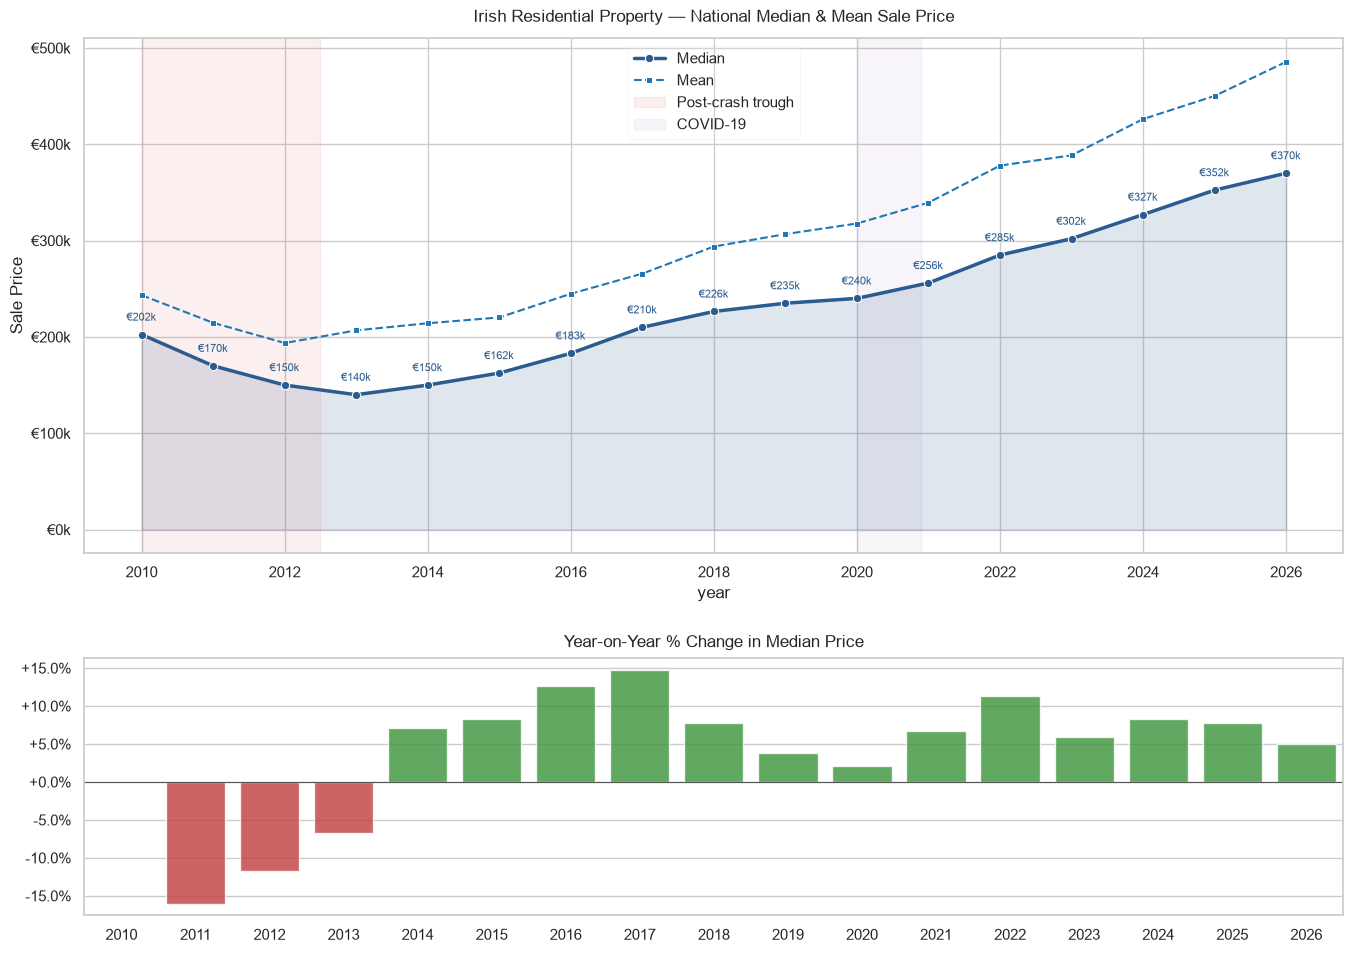

In [7]:
def main():
    # Path to the raw dataset
    file_path = "../data/raw/PPR-ALL.csv"

    # Load the data 
    df = load_data(file_path)
    if df is None:
        print("Failed to load the data")
        return 
    df = standardize(df)
    annual = analysis(df)
    visualisation1(annual)

    
if __name__ == "__main__":
    main()